In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# API gratuita, sin registro, datos reales
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "usd",
    "days": "30",
    "interval": "daily"
}

response = requests.get(url, params=params)
data = response.json()

# Convertir a DataFrame
precios = pd.DataFrame(data["prices"], columns=["timestamp", "precio"])
precios["fecha"] = pd.to_datetime(precios["timestamp"], unit="ms")
precios = precios.drop("timestamp", axis=1)

print(precios.head(10))

         precio      fecha
0  80022.041250 2026-05-08
1  80189.065036 2026-05-09
2  80678.033943 2026-05-10
3  82145.656068 2026-05-11
4  81725.207717 2026-05-12
5  80480.886001 2026-05-13
6  79277.804518 2026-05-14
7  81051.982888 2026-05-15
8  79068.820240 2026-05-16
9  78135.009949 2026-05-17


In [6]:
# Crea tu propio DataFrame desde cero
cryptos = pd.DataFrame({
    "nombre": ["Bitcoin", "Ethereum", "Solana"],
    "precio": [65000, 3200, 150],
    "variacion": [2.5, -1.3, 5.8]
})

print(cryptos)
print("\nLa más cara:", cryptos["precio"].max())
print("Promedio:", cryptos["precio"].mean())

     nombre  precio  variacion
0   Bitcoin   65000        2.5
1  Ethereum    3200       -1.3
2    Solana     150        5.8

La más cara: 65000
Promedio: 22783.333333333332


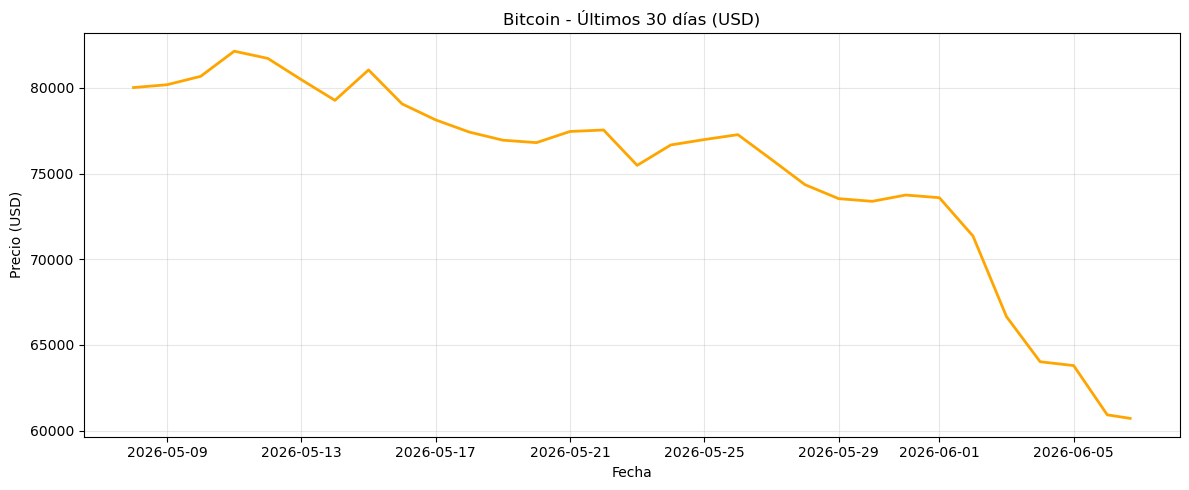

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(precios["fecha"], precios["precio"], color="orange", linewidth=2)
plt.title("Bitcoin - Últimos 30 días (USD)")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

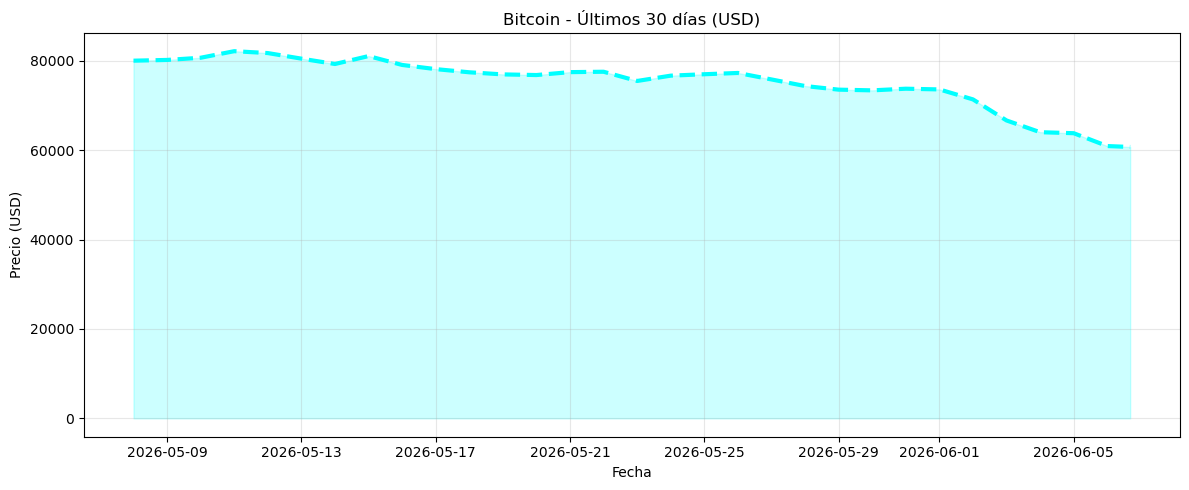

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(precios["fecha"], precios["precio"], color="cyan", linewidth=3, linestyle="--")
plt.fill_between(precios["fecha"], precios["precio"], alpha=0.2, color="cyan")
plt.title("Bitcoin - Últimos 30 días (USD)")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print(" Resumen de Bitcoin últimos 30 días:")
print(f"  Precio máximo:  ${precios['precio'].max():,.2f}")
print(f"  Precio mínimo:  ${precios['precio'].min():,.2f}")
print(f"  Precio promedio: ${precios['precio'].mean():,.2f}")
print(f"  Variación:       ${precios['precio'].max() - precios['precio'].min():,.2f}")

 Resumen de Bitcoin últimos 30 días:
  Precio máximo:  $82,145.66
  Precio mínimo:  $60,716.42
  Precio promedio: $75,074.06
  Variación:       $21,429.24


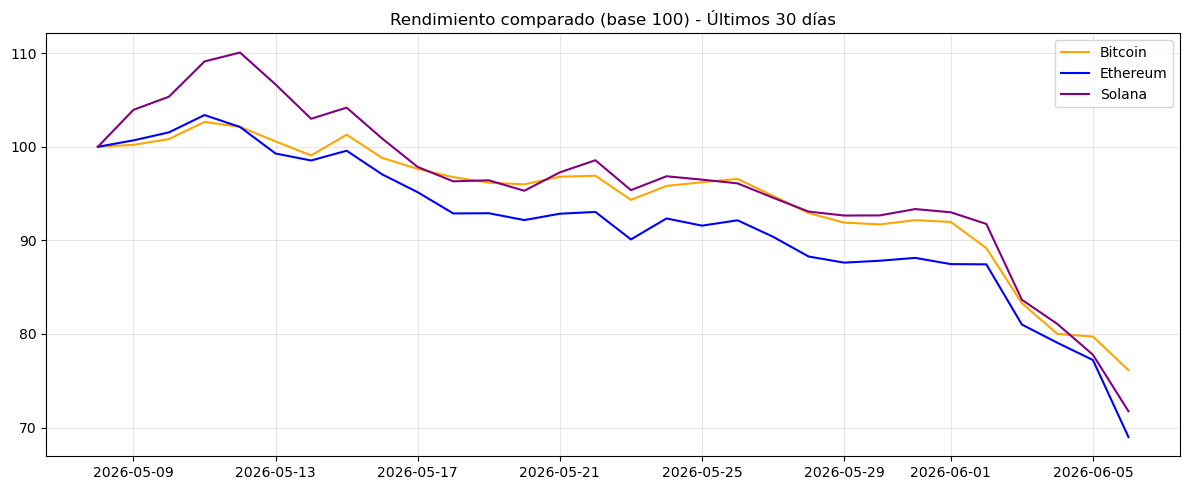

In [10]:
def get_crypto(coin, days=30):
    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params = {"vs_currency": "usd", "days": days, "interval": "daily"}
    data = requests.get(url, params=params).json()
    df = pd.DataFrame(data["prices"], columns=["timestamp", coin])
    df["fecha"] = pd.to_datetime(df["timestamp"], unit="ms")
    return df[["fecha", coin]]

btc = get_crypto("bitcoin")
eth = get_crypto("ethereum")
sol = get_crypto("solana")

# Unir todo
df = btc.merge(eth, on="fecha").merge(sol, on="fecha")

# Normalizar para comparar (base 100)
for col in ["bitcoin", "ethereum", "solana"]:
    df[col] = (df[col] / df[col].iloc[0]) * 100

plt.figure(figsize=(12, 5))
plt.plot(df["fecha"], df["bitcoin"], label="Bitcoin", color="orange")
plt.plot(df["fecha"], df["ethereum"], label="Ethereum", color="blue")
plt.plot(df["fecha"], df["solana"], label="Solana", color="purple")
plt.title("Rendimiento comparado (base 100) - Últimos 30 días")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Alerta de precio
precio_actual = precios["precio"].iloc[-1]  # el precio de hoy
precio_alerta = 70000  # tú decides el límite

print(f"Precio actual de Bitcoin: ${precio_actual:,.2f}")

if precio_actual > precio_alerta:
    print(f"🟢 Bitcoin está POR ENCIMA de tu alerta de ${precio_alerta:,.0f}")
else:
    print(f"🔴 Bitcoin está POR DEBAJO de tu alerta de ${precio_alerta:,.0f}")

# Cuánto falta o cuánto pasó
diferencia = precio_actual - precio_alerta
print(f"Diferencia: ${diferencia:,.2f}")

Precio actual de Bitcoin: $60,716.42
🔴 Bitcoin está POR DEBAJO de tu alerta de $70,000
Diferencia: $-9,283.58


In [ ]:
from groq import Groq

client = Groq(api_key= "api")

# Tomamos los datos que ya tenemos
precio_actual = precios["precio"].iloc[-1]
precio_maximo = precios["precio"].max()
precio_minimo = precios["precio"].min()
precio_promedio = precios["precio"].mean()
variacion = precio_maximo - precio_minimo

respuesta = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "system",
            "content": "Eres un analista financiero experto en criptomonedas. Responde siempre en español de forma clara y concisa."
        },
        {
            "role": "user",
            "content": f"""Analiza estos datos de Bitcoin de los últimos 30 días y dame tu opinión:
            - Precio actual: ${precio_actual:,.2f}
            - Precio máximo: ${precio_maximo:,.2f}
            - Precio mínimo: ${precio_minimo:,.2f}
            - Precio promedio: ${precio_promedio:,.2f}
            - Variación total: ${variacion:,.2f}
            
            ¿Qué tendencia ves? ¿Es buen momento para comprar o vender?"""
        }
    ]
)

print(respuesta.choices[0].message.content)

**Análisis de la tendencia de Bitcoin**

Basándome en los datos proporcionados, puedo observar lo siguiente:

* El precio actual de Bitcoin es de $60,716.42, lo que representa un mínimo en los últimos 30 días.
* El precio máximo alcanzado en este período fue de $82,145.66, lo que indica una caída significativa del 26% en relación con el precio actual.
* La variación total de $21,429.24 sugiere una gran volatilidad en el mercado de Bitcoin en los últimos 30 días.

**Tendencia**

La tendencia actual parece ser bajista, ya que el precio ha caído significativamente desde su máximo en los últimos 30 días. La falta de un fuerte impulso alcista y la presencia de un mínimo reciente sugieren que la tendencia bajista podría continuar en el corto plazo.

**Recomendación**

En este momento, no parece ser un buen momento para comprar Bitcoin, ya que la tendencia es bajista y no hay señales de un cambio de tendencia inminente. Sin embargo, si estás considerando comprar, podrías esperar a que el prec